In [2]:
import os
import os.path as osp
from pathlib import Path
import pandas as pd
import warnings

import yaml

warnings.filterwarnings("ignore")

In [3]:
!nvidia-smi

Thu Nov 28 11:24:53 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.01             Driver Version: 535.183.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 4070 Ti     Off | 00000000:01:00.0  On |                  N/A |
|  0%   39C    P0              44W / 285W |   1180MiB / 12282MiB |      4%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

 ### Load metadata 

In [4]:
import pickle
import yaml

def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

dir_path = "./fungitastic_results/vit224-ft"
train_df, train_preds, train_targs = load_pickle(osp.join(dir_path, "train_preds_targs.pkl"))
test_closed_df, test_preds, test_targs = load_pickle(osp.join(dir_path, "test_preds_targs.pkl"))
test_open_df, open_preds, open_targs = load_pickle(osp.join(dir_path, "open_preds_targs.pkl"))

with open(osp.join(dir_path, "config.yaml"), "r") as f:
    config = yaml.safe_load(f)

### Test model

In [5]:
import sys
import os
%load_ext autoreload
%autoreload 2

SCRIPT_DIR = os.path.dirname(os.path.abspath(os.getcwd()))
sys.path.append(os.path.dirname(SCRIPT_DIR))


In [6]:

from typing import Tuple, Union

import numpy as np
import sklearn.metrics as metrics
from scipy.special import expit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    multilabel_confusion_matrix,
    top_k_accuracy_score,
)
import matplotlib.pyplot as plt
import faiss


def calculate_recall_k(targs, k_closest_classes, k):
    recall_at_k = np.sum(
        [
            1
            for target, recalled_predictions in zip(targs, k_closest_classes)
            if target in recalled_predictions[:k]
        ]
    ) / len(targs)
    return recall_at_k


def calculate_tp_tn(y_true, y_pred, target_class):
    # Convert true and predicted labels to binary for the target class
    true_positive = np.sum((y_true == target_class) & (y_pred == target_class))
    true_negative = np.sum((y_true != target_class) & (y_pred != target_class))
    
    return true_positive, true_negative


def plot_histogram(distances):
    plt.hist(distances, bins=100)
    plt.show()



In [7]:
faiss_gpu_res = faiss.StandardGpuResources()


class KNNClassifier:
    
    def __init__(self, embeddings_dim, n_classes, **kwargs):
        self.embeddings_dim = embeddings_dim
        self.n_classes = n_classes        
        self.kmeans = faiss.Clustering(self.embeddings_dim, self.n_classes)
        self.kmeans.niter = kwargs.get("niter", 40)
        self.kmeans.min_points_per_centroid = kwargs.get("min_points_per_centroid", 1)
        self.kmeans.max_points_per_centroid = kwargs.get("max_points_per_centroid", 1000000000)
        
    def fit(self, preds, targs):
        cpu_cluster_index = faiss.IndexFlatL2(self.embeddings_dim)
        gpu_cluster_index = faiss.index_cpu_to_gpu(faiss_gpu_res, 0, cpu_cluster_index)
        self.kmeans.train(preds, gpu_cluster_index)
        self.train_preds = preds
        self.train_targs = targs
        
    def predict(self, preds, k_values, threshold = None):
        computed_centroids = faiss.vector_float_to_array(self.kmeans.centroids).reshape(
            self.n_classes, self.embeddings_dim
        )
        faiss_search_index = faiss.IndexFlatL2(computed_centroids.shape[-1])
        faiss_search_index = faiss.index_cpu_to_gpu(faiss_gpu_res, 0, faiss_search_index)
        faiss_search_index.add(computed_centroids)
        distances, model_generated_cluster_labels = faiss_search_index.search(preds, 1)  # Classes
        # If threshold is provided, compare distances to threshold and set predictions to -1 if too far
        if threshold is not None:
            # Assign -1 for points with distance greater than the threshold
            model_generated_cluster_labels[distances > threshold] = -1
        
        faiss_search_index = faiss.IndexFlatL2(self.embeddings_dim)
        faiss_search_index = faiss.index_cpu_to_gpu(faiss_gpu_res, 0, faiss_search_index)
        faiss_search_index.add(preds)
        k_distances, k_closest_points = faiss_search_index.search(preds, int(np.max(k_values) + 1))

        faiss_search_index = faiss.IndexFlatL2(self.embeddings_dim)
        faiss_search_index = faiss.index_cpu_to_gpu(faiss_gpu_res, 0, faiss_search_index)
        faiss_search_index.add(self.train_preds)
        k_distances_train, k_closest_points_train = faiss_search_index.search(preds, int(np.max(k_values) + 1))
        k_closest_train_classes = self.train_targs.reshape(-1)[k_closest_points_train[:, 1:]]
        print("Max train distance: ", np.max(k_distances_train[:, 1:]))

        if threshold is not None:
            mask = k_distances_train[:, 1:] > threshold
            k_closest_train_classes[mask] = -1

        return model_generated_cluster_labels, (k_distances, k_closest_points), k_closest_train_classes

kmeans = KNNClassifier(embeddings_dim=config["embeddings_dim"], n_classes=config["number_of_classes"])
kmeans.fit(train_preds, train_targs)

In [13]:


def cluster_classification_scores(
    preds: np.ndarray,
    targs: np.ndarray,
    k_values: tuple,
    *,
    return_dict: bool = True,
    clustering_kws: dict = None,
) -> Union[dict, Tuple]:

    preds = np.vstack(preds).astype("float32")
    targs = np.hstack(targs).reshape(-1, 1)
    model_generated_cluster_labels, (k_distances, k_closest_points), k_closest_classes_train = (kmeans.predict(preds, k_values, threshold=clustering_kws.get("threshold", None)))
    k_closest_classes = targs.reshape(-1)[k_closest_points[:, 1:]]

    true_unknown_indexes = np.arange(len(targs))[targs.reshape(-1) == -1]
    predicted_unknown_indexes = np.arange(len(targs))[k_closest_classes_train[:, 0] == -1]
    print("TP unknown", sum([1 for p in predicted_unknown_indexes if p in true_unknown_indexes]), f"From {len(true_unknown_indexes)} / {len(predicted_unknown_indexes)}")

    # Calculate scores
    f1 = f1_score(targs, k_closest_classes[:, 0], average="macro")
    f1_train = f1_score(targs, k_closest_classes_train[:, 0], average="macro")

    nmi_score = metrics.cluster.normalized_mutual_info_score(
        model_generated_cluster_labels.reshape(-1), targs.reshape(-1)
    )
    recall_all_k = []
    for k in k_values:
        recall_at_k = calculate_recall_k(targs, k_closest_classes, k)
        recall_at_k_train = calculate_recall_k(targs, k_closest_classes_train, k)
        recall_all_k.append((recall_at_k, recall_at_k_train))

    if return_dict:
        scores = {
            "NMI": nmi_score,
            "F1": (f1, f1_train),
        }
        for k, recall in zip(k_values, recall_all_k):
            scores[f"Recall@{k}"] = recall
    else:
        scores = nmi_score, *recall_all_k

    return scores

# print(cluster_classification_scores(train_preds, train_targs, k_values = [1, 3, 8], clustering_kws={}))
# print(cluster_classification_scores(test_preds, test_targs, k_values = [1, 3, 8], clustering_kws={}))
# print(cluster_classification_scores(open_preds, open_targs, k_values = [1, 3, 8], clustering_kws={"threshold": 0.8}))
for threshold in [0.6, 0.7, 0.8, 0.9 ]:
    print(f"Threshold: {threshold}")
    print(cluster_classification_scores(open_preds, open_targs, k_values = [1, 3, 8], clustering_kws={"threshold": threshold}))

"""
open set (96 756 samples), thresholding based on the distance from train set samples
Threshold: 0.6
TP unknown 5122 From 7097 / 25949 (real / predicted)

Threshold: 0.7
TP unknown 3894 From 7097 / 18733 (real / predicted)

Threshold: 0.8
TP unknown 2636 From 7097 / 12527 (real / predicted)

Threshold: 0.9
TP unknown 1439 From 7097 / 7260 (real / predicted)
"""

Threshold: 0.6
Max train distance:  1.3387976
TP unknown 5122 From 7097 / 25949
{'NMI': 0.7223413529013829, 'F1': (0.46624714033770986, 0.3936803475313186), 'Recall@1': (0.669384844350738, 0.6361569308363305), 'Recall@3': (0.717536896936624, 0.6747281822315929), 'Recall@8': (0.7339389805283393, 0.6956777874240357)}
Threshold: 0.7
Max train distance:  1.3387976
TP unknown 3894 From 7097 / 18733
{'NMI': 0.7465788051891814, 'F1': (0.49244849498755505, 0.3961413079228523), 'Recall@1': (0.6966906445078341, 0.6507193352350242), 'Recall@3': (0.7569556409938402, 0.6980859068171483), 'Recall@8': (0.7802823597502997, 0.7250299723014594)}
Threshold: 0.8
Max train distance:  1.3387976
TP unknown 2636 From 7097 / 12527
{'NMI': 0.7625701985087266, 'F1': (0.5084131557770911, 0.3918043685060616), 'Recall@1': (0.7141675968415395, 0.6546364049774691), 'Recall@3': (0.7849849104965066, 0.7073153086113523), 'Recall@8': (0.8150295588904047, 0.7388275662491215)}
Threshold: 0.9
Max train distance:  1.3387976


'\nopen set (96 756 samples): Threshold: 0.6\nTP unknown 5122 From 7097 / 25949\n'

In [12]:
len(open_targs)

96756

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb2b61e2200>
Traceback (most recent call last):
  File "/home/marek/miniconda3/envs/py311/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/marek/miniconda3/envs/py311/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/marek/miniconda3/envs/py311/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/marek/miniconda3/envs/py311/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
A

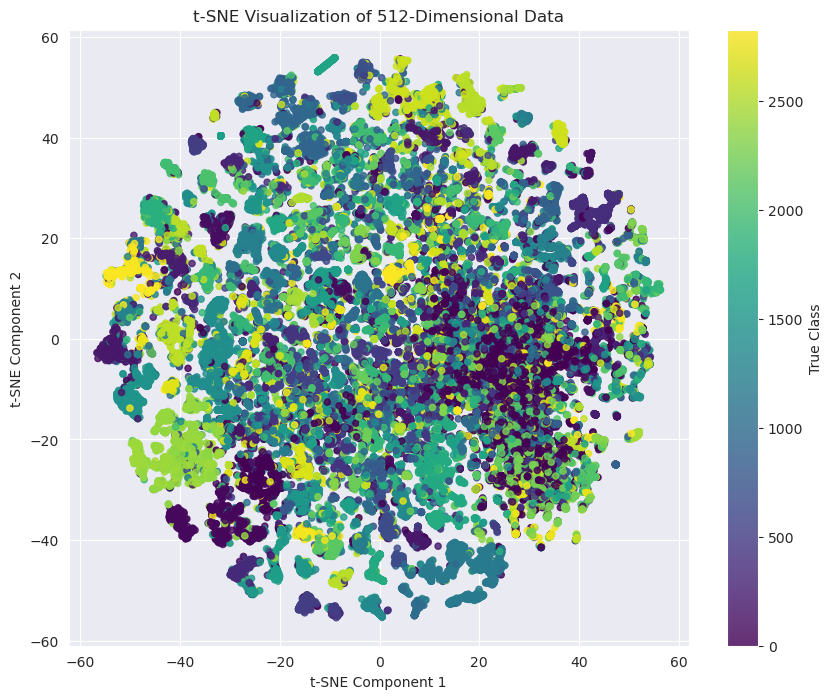

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb222761440>
Traceback (most recent call last):
  File "/home/marek/miniconda3/envs/py311/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/marek/miniconda3/envs/py311/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/marek/miniconda3/envs/py311/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/marek/miniconda3/envs/py311/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
A

KeyboardInterrupt: 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Example: Generate synthetic data
# Assume `n` samples with 512 dimensions

# Step 1: Apply t-SNE to reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
data_2d = tsne.fit_transform(open_preds)

# Step 2: Plot the 2D t-SNE result
plt.figure(figsize=(10, 8))
scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=open_targs, cmap='viridis', s=20, alpha=0.8)

# Step 3: Add colorbar and labels
plt.colorbar(scatter, label='True Class')
plt.title("t-SNE Visualization of 512-Dimensional Data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

tsne = TSNE(n_components=3, random_state=42, perplexity=30, learning_rate=200)
data_3d = tsne.fit_transform(open_preds)

# Step 2: Plot the 2D t-SNE result
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Step 3: Scatter plot with 3 PCA components and color based on targs
scatter = ax.scatter(data_3d[:, 0], data_3d[:, 1], data_3d[:, 2], c=open_targs, cmap='viridis', s=20, alpha=0.8)

ax.set_title('t-SNE Visualization of 512-Dimensional Data')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')
fig.colorbar(scatter, ax=ax, label='True Class')
plt.show()


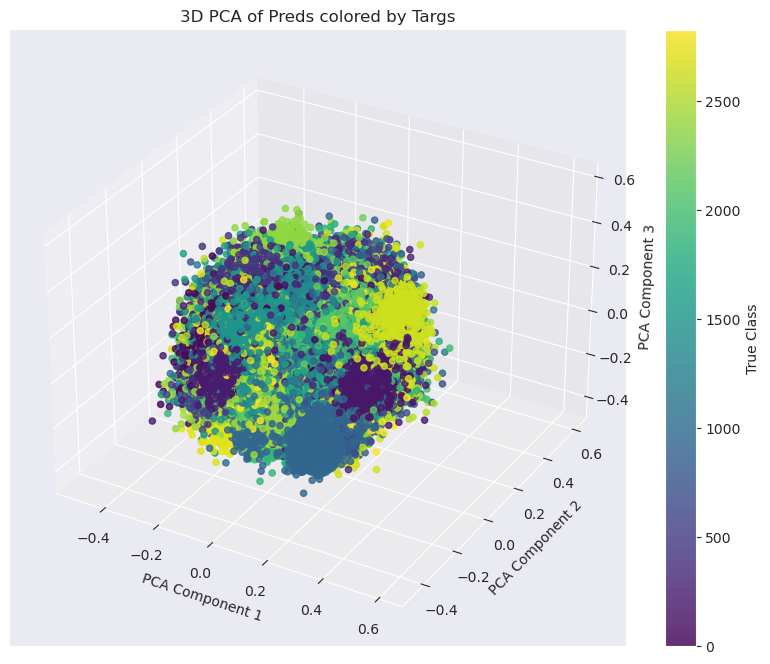

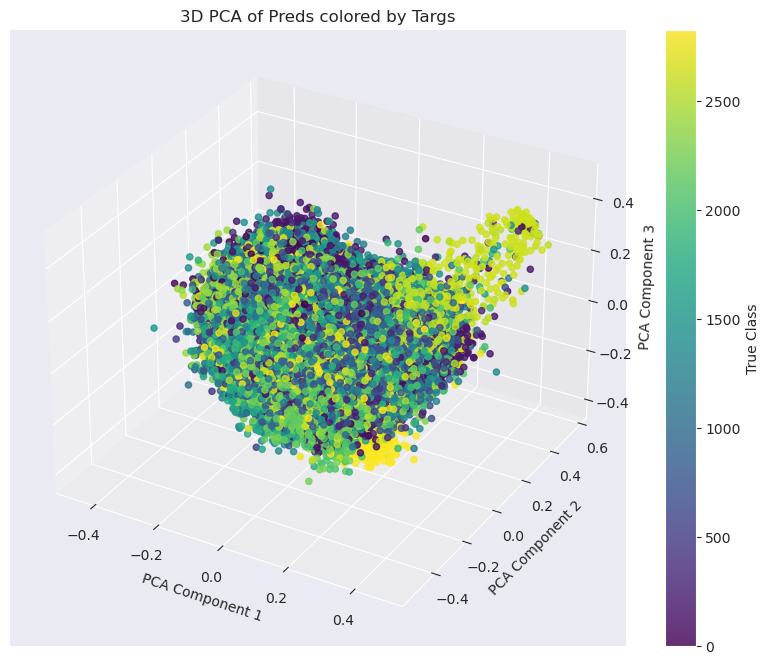

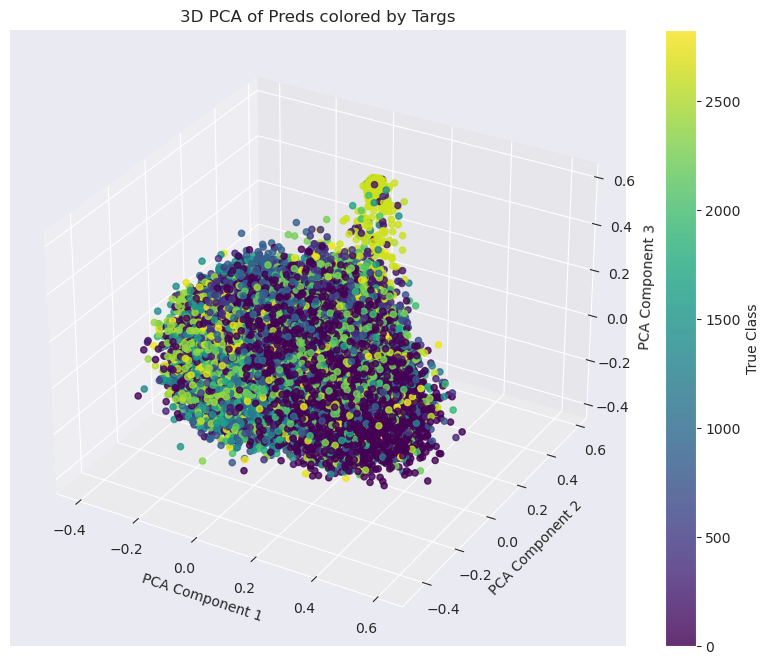

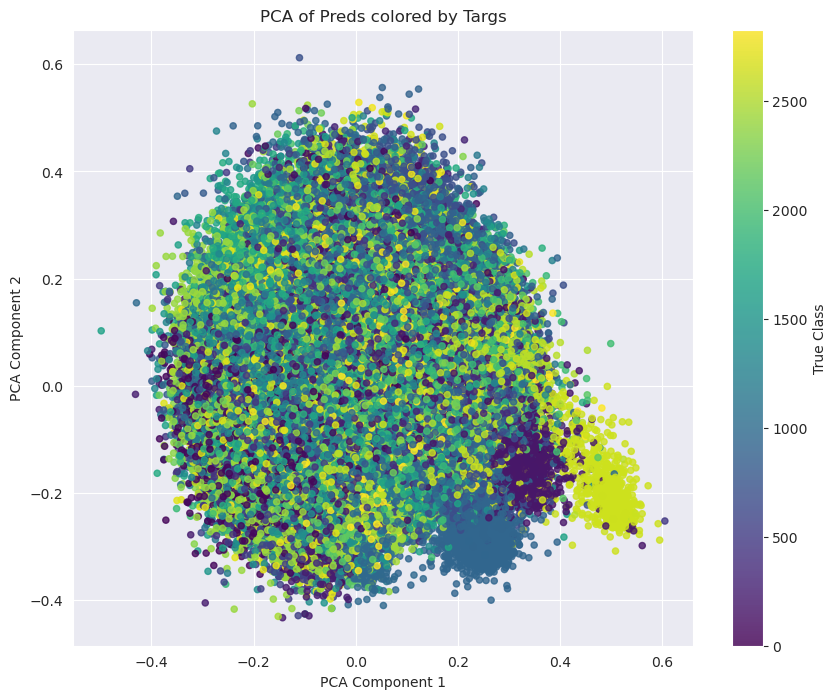

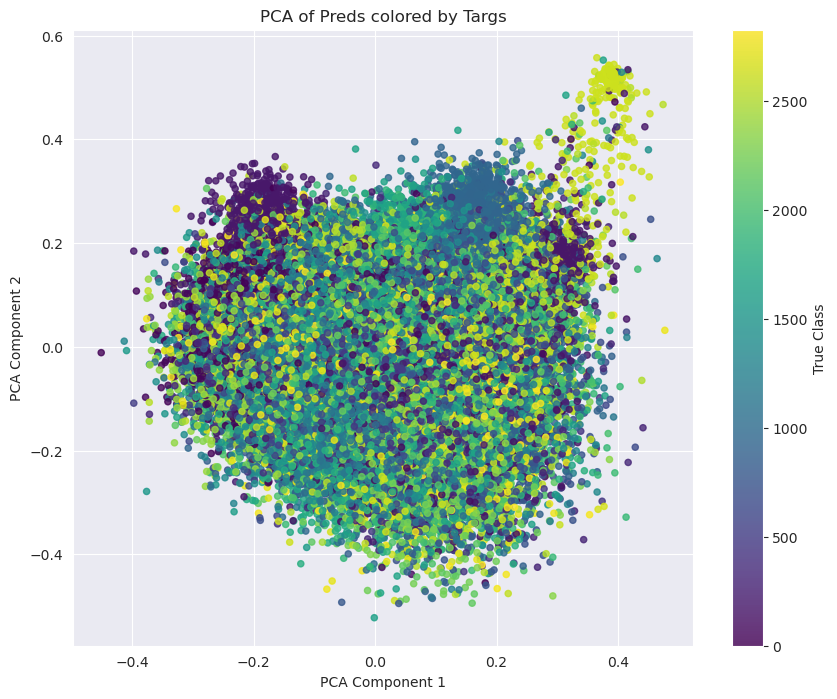

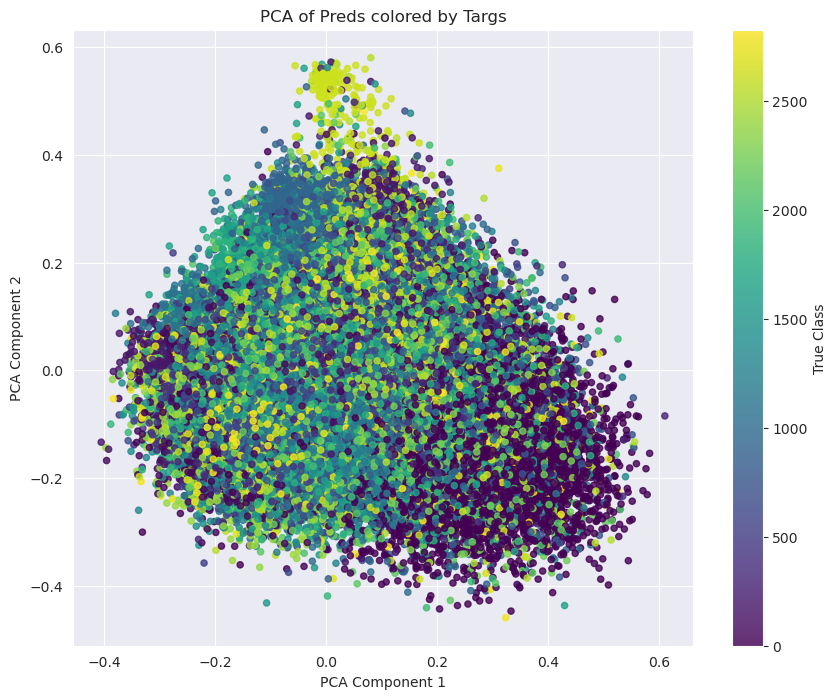

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

def plot_pca(preds: np.ndarray, targs: np.ndarray):
    # Step 1: Apply PCA to reduce preds to 2 components
    pca = PCA(n_components=3)
    preds_pca = pca.fit_transform(preds)

    # Step 2: Plot the PCA components, color-coded by targs
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Step 3: Scatter plot with 3 PCA components and color based on targs
    scatter = ax.scatter(preds_pca[:, 0], preds_pca[:, 1], preds_pca[:, 2], c=targs, cmap='viridis', s=20, alpha=0.8)

    # Step 4: Add labels and color bar
    ax.set_title('3D PCA of Preds colored by Targs')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.set_zlabel('PCA Component 3')
    fig.colorbar(scatter, ax=ax, label='True Class')

    # Step 4: Show plot
    plt.show()
    
def plot_pca_2d(preds: np.ndarray, targs: np.ndarray):
    # Step 1: Apply PCA to reduce preds to 2 components
    pca = PCA(n_components=2)
    preds_pca = pca.fit_transform(preds)

    # Step 2: Plot the PCA components, color-coded by targs
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(preds_pca[:, 0], preds_pca[:, 1], c=targs, cmap='viridis', s=20, alpha=0.8)

    # Step 3: Add colorbar and labels
    plt.colorbar(scatter, label='True Class')
    plt.title('PCA of Preds colored by Targs')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')

    # Step 4: Show plot
    plt.show()    
    

# Example usage
plot_pca(train_preds, train_targs)
plot_pca(test_preds, test_targs)
plot_pca(open_preds, open_targs)

plot_pca_2d(train_preds, train_targs)
plot_pca_2d(test_preds, test_targs)
plot_pca_2d(open_preds, open_targs)


## Running Sweep Training 

In [9]:
# Change sweep configuration if needed
# !wandb sweep ../sweep_configs/DF24M_224.yaml

In [10]:
# !wandb agent <WANDB_ENTITY>/<WANDB_PROJECT>...